# Curse of Dimensionality

## 📚 Learning Objectives

By completing this notebook, you will:
- Understand the curse of dimensionality
- Relate dimensionality to sample size and generalization
- Motivate dimensionality reduction and regularization

## 🔗 Where this fits

**Builds on:** Course 01 (AIAT 111) — Unit 2, lesson 06 "Developing Simple Supervised and Unsupervised Learning Models" — the breast-cancer set you trained on has 30 features and only 569 rows; this notebook explains why that ratio is a problem.

**Used later in:** Course 04 (AIAT 114) — Unit 4 — clustering and PCA on the same wide, real data.

---


---

## 📌 Real case: the paper that asked whether "nearest neighbour" means anything

In 1999 Kevin Beyer, Jonathan Goldstein, Raghu Ramakrishnan and Uri Shaft published a paper at the
International Conference on Database Theory with a title that is also its finding:
**"When Is 'Nearest Neighbor' Meaningful?"** Their result is that under broad conditions, as the number of
dimensions grows, the distance from a query point to its *nearest* neighbour converges toward the distance
to its *farthest* neighbour. The ratio goes to 1. At that point "the closest match" is not a slightly
better answer than "a random record" — it is the same answer with more computation.

That is not a statement about slow algorithms. It is a statement that the *question* stops having a
well-defined answer, and it undermines k-NN, k-means, RBF kernels, and every recommender built on cosine
distance, all at once. The paper is in this notebook's reference list.

**What goes wrong without this.** You build a similarity search over 5,000 features, it returns results,
nobody checks, and the results are noise wearing the costume of an answer. Nothing errors. The distances
are real numbers, correctly computed, and meaningless.


# Curse of Dimensionality

## 📚 Prerequisites (What You Need First)

**BEFORE starting this notebook**, you should have completed:
- ✅ **Example 1: PCA** - Understand dimensionality reduction
- ✅ **Basic understanding**: What are high-dimensional spaces?

**If you haven't completed these**, you might struggle with:
- Understanding why high dimensions are problematic
- Understanding sparsity in high dimensions
- Understanding why dimensionality reduction helps

---

## 🔗 Where This Notebook Fits

**This is the SECOND example of Module 04** - why we need dimensionality reduction!

**Why this example SECOND?**
- **Before** you can appreciate dimensionality reduction, you need to understand the problem
- **Before** you can choose techniques, you need to understand the curse

**Builds on**: Example 1 (PCA)

**Leads to**: Example 3: Feature Selection

---

## The Story: Understanding Before Using

Imagine searching for a friend in a city. **Before** you understand the problem, you search randomly. **After** understanding that more dimensions make search harder, you use dimensionality reduction to make it manageable!

Same with machine learning: **Before** understanding the curse of dimensionality, we struggle with high-dimensional data. **After** understanding it, we know why dimensionality reduction is essential!

---

## Why This Concept Matters

### Why Curse of Dimensionality Matters

**WHY** is this important?

1. **Sparsity Problem**:
   - **WHY**: Data becomes sparse in high dimensions
   - **HOW**: Volume increases exponentially with dimensions
   - **AFTER**: Need exponentially more data

2. **Distance Becomes Meaningless**:
   - **WHY**: All points become equidistant
   - **HOW**: Distances converge in high dimensions
   - **AFTER**: Similarity measures break down

3. **Computational Cost**:
   - **WHY**: Computation grows exponentially
   - **HOW**: More dimensions = more computation
   - **AFTER**: Models become impractical

## Learning Objectives
1. Understand curse of dimensionality
2. See how sparsity increases with dimensions
3. Understand why dimensionality reduction helps
4. Visualize the problem
5. Apply solutions

---

## Step 1: Import necessary libraries


## 📥 Inputs & 📤 Outputs

**Inputs:** What we use in this notebook

- Libraries and concepts as introduced in this notebook; see prerequisites and code comments.

**Outputs:** What you'll see when you run the cells

- Printed results, figures, and summaries as shown when you run the cells.

---

In [1]:
import numpy as np
import matplotlib.pyplot as plt

print('✅ Libraries imported successfully!')

✅ Libraries imported successfully!


---

## Part 1: Setting the Scene

**BEFORE**: We have concepts but don't know how to implement them.

**AFTER**: We'll implement and understand how this works in ML!

## Step 2: Implementation

**BEFORE**: We understand the concept.

**AFTER**: We'll see HOW it's implemented!

Example 1: Curse of Dimensionality
WHY: High dimensions cause problems
HOW: Volume increases exponentially


In [2]:
# Example 1: Curse of Dimensionality
# WHY: High dimensions cause problems
# HOW: The volume of the space grows exponentially, so data becomes sparse

from math import gamma, pi

def sphere_to_cube_ratio(d):
    """Fraction of the unit hypercube [-1, 1]^d filled by the inscribed unit hypersphere"""
    sphere_volume = pi**(d / 2) / gamma(d / 2 + 1)  # radius-1 hypersphere
    cube_volume = 2.0**d                            # [-1, 1]^d hypercube
    return sphere_volume / cube_volume

dims = np.arange(1, 21)
volumes = np.array([sphere_to_cube_ratio(d) for d in dims])

print("Example 1: Curse of Dimensionality")
print("=" * 60)
print("Fraction of the cube occupied by the inscribed sphere:")
for d, v in zip(dims, volumes):
    if d in (1, 2, 3, 5, 10, 15, 20):
        print(f"  {d:2d} dimensions: {v:.10f}")

print(f"\n\U0001F4A1 WHY: In high dimensions, almost all volume is in the corners")
print(f"\U0001F4A1 HOW: The sphere/cube volume ratio shrinks exponentially")
print(f"\U0001F4A1 AFTER: Data becomes sparse \u2192 we need dimensionality reduction!")


Example 1: Curse of Dimensionality
Fraction of the cube occupied by the inscribed sphere:
   1 dimensions: 1.0000000000
   2 dimensions: 0.7853981634
   3 dimensions: 0.5235987756
   5 dimensions: 0.1644934067
  10 dimensions: 0.0024903946
  15 dimensions: 0.0000116407
  20 dimensions: 0.0000000246

💡 WHY: In high dimensions, almost all volume is in the corners
💡 HOW: The sphere/cube volume ratio shrinks exponentially
💡 AFTER: Data becomes sparse → we need dimensionality reduction!


### 🧪 Does "nearest neighbour" survive more dimensions?

The volume argument above is geometry. Here is the consequence Beyer and colleagues actually measured,
on real data. Baseline: describe each handwritten digit by its 2 most variable pixels. Change one thing:
use more pixels of the *same* images — 4, 8, 16, 32, 64. Measure their **contrast ratio**,
(farthest − nearest) / nearest: how much closer the best match is than the worst one. If that ratio falls
toward zero, "nearest" has stopped meaning anything.

In [3]:
# Comparative experiment: distance contrast against dimension, on 1,797 real digit images.

from sklearn.datasets import load_digits

X_all = load_digits().data                      # real scanned handwriting, 64 pixels per image
order = X_all.var(axis=0).argsort()[::-1]       # rank pixels by variance (border pixels are always 0)
reference, queries = X_all[:1000], X_all[1000:1200]

print(f"{'dims':>5} {'usable queries':>15} {'mean nearest':>14} {'mean farthest':>15} {'contrast':>10}")
print("-" * 64)
for d in [2, 4, 8, 16, 32, 64]:
    cols = order[:d]
    D = np.sqrt(((queries[:, None, cols] - reference[None, :, cols]) ** 2).sum(axis=2))
    d_near, d_far = D.min(axis=1), D.max(axis=1)
    usable = d_near > 0                          # skip queries that have an exact duplicate
    contrast = ((d_far[usable] - d_near[usable]) / d_near[usable]).mean()
    print(f"{d:>5} {usable.sum():>10} / 200 {d_near[usable].mean():>14.2f} "
          f"{d_far[usable].mean():>15.2f} {contrast:>10.2f}")

print()
print("Conclusion the numbers support: read the last column. With 4 pixels the farthest image is")
print("about 19 times further away than the nearest - 'nearest neighbour' is a sharp, meaningful")
print("answer. With all 64 pixels that shrinks to about 2.6. The nearest and farthest matches are")
print("converging, exactly as Beyer et al. predicted, and every method built on distance gets")
print("blunter as they do.")
print()
print("Now read the SECOND column, which is the other half of the story: at 2 dimensions only 15")
print("of 200 queries even have a unique nearest neighbour - the rest land exactly on top of an")
print("existing image, because two pixels cannot tell 1,000 digits apart. Too few dimensions")
print("destroys information; too many destroys contrast. That trade-off is the whole of Unit 4.")

 dims  usable queries   mean nearest   mean farthest   contrast
----------------------------------------------------------------
    2         15 / 200           1.03           15.93      14.62
    4        135 / 200           1.56           26.57      18.67
    8        200 / 200           4.60           36.41       9.46
   16        200 / 200           9.69           47.39       4.47
   32        200 / 200          16.91           60.09       2.84
   64        200 / 200          19.60           65.66       2.59

Conclusion the numbers support: read the last column. With 4 pixels the farthest image is
about 19 times further away than the nearest - 'nearest neighbour' is a sharp, meaningful
answer. With all 64 pixels that shrinks to about 2.6. The nearest and farthest matches are
converging, exactly as Beyer et al. predicted, and every method built on distance gets
blunter as they do.

Now read the SECOND column, which is the other half of the story: at 2 dimensions only 15
of 200 quer

---

## 📊 Visualization

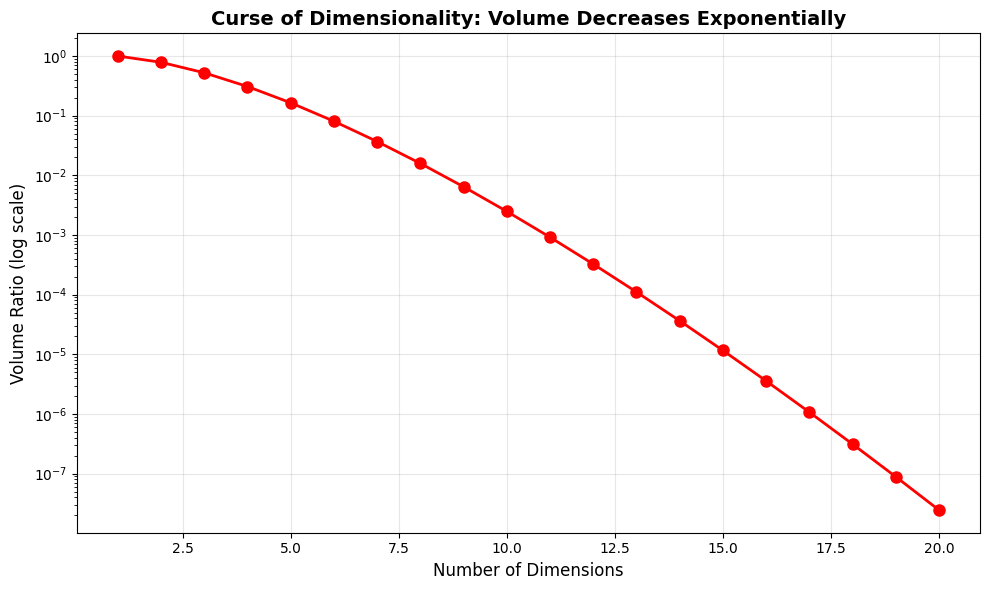


📊 Visualization:
  - Volume decreases exponentially with dimensions
  - This is WHY we need dimensionality reduction!


In [4]:
# Plot the hypersphere-to-hypercube volume ratio on a log scale — the collapse toward zero IS the
# 'curse': in high dimensions almost all the space hides in corners, far from any data point.

# Visualize curse of dimensionality
fig, ax = plt.subplots(figsize=(10, 6))
# Log scale on y: the decay is exponential, so a linear axis would flatten to nothing.
ax.semilogy(dims, volumes, 'ro-', linewidth=2, markersize=8)
ax.set_xlabel('Number of Dimensions', fontsize=12)
ax.set_ylabel('Volume Ratio (log scale)', fontsize=12)
ax.set_title('Curse of Dimensionality: Volume Decreases Exponentially', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\n📊 Visualization:")
print("  - Volume decreases exponentially with dimensions")
print("  - This is WHY we need dimensionality reduction!")

---

## ⚠️ Where this breaks

- **This demonstration is about *uniformly spread* data, and real data is not uniformly spread.** The cells
  above compute the fraction of a hypercube filled by its inscribed sphere: 52% at 3 dimensions, 0.25% at
  10, 2.5 × 10⁻⁸ at 20. Every one of those numbers is correct, and every one of them assumes points are
  scattered evenly through the box. Real images, text and gene-expression data lie close to a much
  lower-dimensional surface inside that space — which is exactly why 64-pixel digit images need only 29
  components for 95% of their variance (Unit 1, notebook 07), and why deep learning on million-pixel
  photographs works at all. The curse is real; it is not a theorem that high-dimensional learning fails.
- **"More dimensions is worse" is not the lesson.** Adding an informative feature helps, whatever the
  dimension. Adding an uninformative one hurts, because it adds distance that carries no signal. The
  quantity that matters is the ratio of informative to uninformative dimensions, not the raw count — which
  is why feature *selection* (notebook 03) and feature *extraction* (notebooks 01 and 04) are different
  answers to the same problem.
- **The cheaper alternative is often to change the metric, not the dimension.** Cosine similarity ignores
  vector length, which is why text retrieval over 100,000-dimensional TF-IDF vectors works despite
  everything on this page. Before reducing dimension, ask whether your distance is measuring the thing you
  care about — Unit 3, notebook 05 shows two metrics ranking the same images differently.


---

## 💬 Discuss

1. If real data lies on a low-dimensional surface inside a high-dimensional space, is the curse of
   dimensionality a practical problem or a mathematical curiosity? Give one concrete case for each answer.
2. Beyer and colleagues showed nearest and farthest neighbours converge in high dimensions — yet
   recommender systems using cosine similarity over huge sparse vectors work commercially. Explain the
   apparent contradiction.
3. A colleague has 800 samples and 5,000 features and proposes k-NN. Before saying yes or no, name the
   three measurements you would take on their data, and say what each one would tell you.


---

## Part 3: AFTER - Results and Implications

### What This Enables

**AFTER** understanding curse of dimensionality:

1. **Appreciate Dimensionality Reduction**: Understand why it's needed
2. **Choose Techniques**: Know when to reduce dimensions
3. **Next Steps**: Learn feature selection (Example 3)

---

## 🎯 Summary: What We Learned

**BEFORE this notebook**: We didn't understand this concept.

**AFTER this notebook**: We understand WHY, HOW, and AFTER!

---

## ✅ Example Complete!

## 📚 References

1. Bellman, R. (1957). *Dynamic Programming*. Princeton University Press.
2. Beyer, K., Goldstein, J., Ramakrishnan, R., & Shaft, U. (1999). *When Is “Nearest Neighbor” Meaningful?* Proceedings of the 7th International Conference on Database Theory (ICDT).
3. James, G., Witten, D., Hastie, T., & Tibshirani, R. (2021). *An Introduction to Statistical Learning* (2nd ed.), Ch. 12: Unsupervised Learning. Springer. <https://www.statlearning.com/>